# Alliance Expansion + Media Deal Governance Vote Model

This notebook models how the 18 heads of school might vote on three separate governance questions:

1. **Expansion Vote** — Should the Alliance expand from 14 to 18 schools?
2. **Media Deal Vote** — Should the Alliance accept the Nexus Sports multimedia rights agreement?
3. **Distribution Vote** — Should the Alliance adopt a hybrid distribution model instead of pure equal distributions?

The model is intentionally transparent. It is not trained on historical voting data. It is a decision-support model that converts school profiles, incentives, and political assumptions into predicted voting probabilities. You can edit the assumptions, weights, and school profiles to test different scenarios.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
np.random.seed(42)

## 2. Contract assumptions

The Nexus deal is modeled as:

- 18 member institutions
- $2,700,000 annual rights fee
- $150,000 per school under pure equal distribution
- Proposed hybrid model: $125,000 guaranteed base per school plus a $450,000 league-wide performance pool

In [2]:
ANNUAL_RIGHTS_FEE = 2_700_000
NUM_SCHOOLS = 18
EQUAL_PAYOUT = ANNUAL_RIGHTS_FEE / NUM_SCHOOLS
HYBRID_BASE = 125_000
HYBRID_PERFORMANCE_POOL = ANNUAL_RIGHTS_FEE - (HYBRID_BASE * NUM_SCHOOLS)

print(f"Annual rights fee: ${ANNUAL_RIGHTS_FEE:,.0f}")
print(f"Equal payout per school: ${EQUAL_PAYOUT:,.0f}")
print(f"Hybrid base payout per school: ${HYBRID_BASE:,.0f}")
print(f"Hybrid performance pool: ${HYBRID_PERFORMANCE_POOL:,.0f}")

Annual rights fee: $2,700,000
Equal payout per school: $150,000
Hybrid base payout per school: $125,000
Hybrid performance pool: $450,000


## 3. Build the school profile dataset

This dataset includes the 14 current Alliance members plus the 4 proposed expansion members: Washington Latin, Bergen Central, Lincoln-Way East, and Carmel.

The profile includes hard variables and modeled political variables. The modeled variables are meant to be editable.

In [3]:
school_rows = [
    ["City College (MD)","Current","East",5.8,8621,11000,0.78,"Elite National / Flagship",7,0,0,0.98,0.55,0.90,0.55,0.55,0.45,0.55,0.55,0.95,0.35,0.30,0.40,0.55,0.55,"Flagship dynasty; likely to support growth and media upside, but wants premium-value recognition."],
    ["Central (PA)","Current","East",6.3,4775,7500,0.64,"National / Historic",8,0,0,0.70,0.45,0.88,0.75,0.45,0.35,0.55,0.50,0.60,0.50,0.45,0.45,0.55,0.70,"Historic Philadelphia brand; likes Palumbo/Washington Latin inventory but favors political stability."],
    ["PG Poly (MD)","Current","East",6.4,2585,5500,0.47,"Regional Upside",0,0,0,0.45,0.30,0.75,0.70,0.50,0.25,0.70,0.65,0.25,0.75,0.65,0.45,0.45,0.85,"Benefits from DMV growth, but needs guaranteed resources and worries about competitive squeeze."],
    ["Brooklyn Tech (NY)","Current","East",20.1,4135,5500,0.75,"Major-Market Upside",0,0,0,0.62,0.40,0.82,0.70,0.75,0.35,0.45,0.45,0.55,0.55,0.45,0.45,0.50,0.70,"Large market and rising profile; likes upside but wants a protected base."],
    ["Ramsey (NJ)","Current","East",20.1,4180,5500,0.76,"Major-Market Strong",3,0,0,0.73,0.35,0.85,0.90,0.65,0.25,0.65,0.60,0.60,0.50,0.45,0.45,0.50,0.70,"Bergen Central creates a premium rivalry, but also a direct North Jersey threat."],
    ["Phoebus (VA)","Current","East",1.86,4885,8500,0.57,"Regional Strong",0,0,0,0.50,0.30,0.76,0.30,0.25,0.45,0.55,0.55,0.35,0.70,0.55,0.45,0.45,0.80,"Regional football value, but expansion does not obviously improve their path or costs."],
    ["Oscar Smith (VA)","Current","East",1.7,6415,10000,0.64,"Regional Strong+",0,0,0,0.72,0.35,0.80,0.35,0.30,0.45,0.50,0.45,0.65,0.55,0.45,0.40,0.50,0.60,"Strong football brand that expects premium exposure and bonus-pool upside."],
    ["Canton McKinley (OH)","Current","West",0.98,5252,23000,0.23,"Historic / Event Venue",2,0,0,0.38,0.35,0.78,0.25,0.25,0.35,0.55,0.55,0.35,0.70,0.70,0.55,0.55,0.85,"Historic venue, but low utilization and current competitive risk push toward stability."],
    ["Mount Carmel (IL)","Current","West",9.4,2988,5000,0.60,"Large-Market Regional",0,0,0,0.52,0.35,0.78,0.55,0.60,0.20,0.70,0.65,0.30,0.70,0.60,0.45,0.45,0.80,"Chicagoland value, but Lincoln-Way East may dilute their regional leverage."],
    ["Steubenville (OH)","Current","West",0.13,8954,15000,0.60,"Elite National / Cult Brand",12,0,0,0.85,0.35,0.90,0.40,0.35,0.35,0.45,0.40,0.90,0.40,0.50,0.45,0.60,0.55,"Small-market national brand; likely to favor growth and a reward for premium inventory."],
    ["Male (KY)","Current","West",1.3,4012,10000,0.40,"Regional Historic",1,0,0,0.48,0.35,0.75,0.30,0.30,0.45,0.60,0.60,0.25,0.75,0.55,0.45,0.45,0.85,"Regional historic program; prefers predictable subsidy and worries about competition."],
    ["East St. Louis (IL)","Current","West",2.8,4755,8000,0.59,"Regional Strong",1,0,0,0.68,0.40,0.80,0.85,0.60,0.20,0.55,0.50,0.55,0.60,0.50,0.45,0.50,0.70,"Likes Lincoln-Way East rivalry inventory but still values guaranteed support."],
    ["Moeller (OH)","Current","West",2.3,2751,5500,0.50,"Historic National",5,0,0,0.55,0.40,0.82,0.35,0.35,0.35,0.45,0.45,0.50,0.55,0.45,0.45,0.55,0.70,"Historic brand with uneven current value; likely prefers hybrid compromise."],
    ["Massillon (OH)","Current","West",0.98,8614,17000,0.51,"Elite National",10,0,0,0.92,0.35,0.90,0.40,0.35,0.35,0.45,0.40,0.90,0.40,0.45,0.45,0.60,0.55,"Elite national football brand; supports deal but wants performance upside."],
    ["Washington Latin (DC)","Expansion","East",6.4,3221,3500,3221/3500,"High-Value Emerging",0,1,1,0.78,0.90,0.92,0.85,0.85,0.25,0.40,0.35,0.65,0.45,0.70,0.45,0.50,0.75,"Two-sport DC public-exam brand; likely supports package but wants new-member stability."],
    ["Bergen Central (NJ)","Expansion","East",19.9,6640,7000,6640/7000,"Major-Market Strong",0,1,1,0.66,0.30,0.88,0.90,0.90,0.25,0.40,0.35,0.65,0.45,0.45,0.40,0.50,0.65,"North Jersey media/attendance add; expects premium rivalry windows with Ramsey."],
    ["Lincoln-Way East (IL)","Expansion","West",0.5,5162,5000,5162/5000,"Football-First Strong",0,1,1,0.80,0.35,0.84,0.85,0.60,0.20,0.40,0.35,0.70,0.45,0.45,0.40,0.50,0.60,"Football-first Illinois add; likely expects bonus-pool upside from strong event demand."],
    ["Carmel (IN)","Expansion","West",2.2,5293,10000,5293/10000,"All-Sports Strong",0,1,1,0.76,0.85,0.88,0.70,0.70,0.25,0.40,0.35,0.65,0.45,0.40,0.40,0.50,0.70,"All-sports infrastructure add; likely supports media package and hybrid distribution."]
]

columns = ["School","Status","Division","MSA","FB_Attendance","FB_Capacity","Utilization","Media_Tier","FB_Titles","Expansion_Target","New_Member","Recent_FB_Strength","Basketball_Value","Institutional_Fit","Rivalry_Gain_From_Expansion","Market_Gain_From_Expansion","Travel_Burden_Added","Competitive_Threat","Playoff_Access_Risk","Expected_T1","Budget_Need","Facility_Compliance_Cost","Local_Control_Concern","IP_Concern","League_Unity_Preference","Vote_Blurb"]

df = pd.DataFrame(school_rows, columns=columns)
df["FB_Attendance"] = df["FB_Attendance"].round(0).astype(int)
df.head()


,School,Status,Division,MSA,FB_Attendance,FB_Capacity,Utilization,Media_Tier,FB_Titles,Expansion_Target,New_Member,Recent_FB_Strength,Basketball_Value,Institutional_Fit,Rivalry_Gain_From_Expansion,Market_Gain_From_Expansion,Travel_Burden_Added,Competitive_Threat,Playoff_Access_Risk,Expected_T1,Budget_Need,Facility_Compliance_Cost,Local_Control_Concern,IP_Concern,League_Unity_Preference,Vote_Blurb
0,City College (MD),Current,East,5.8,8621,11000,0.78,Elite National / Flagship,7,0,0,0.98,0.55,0.90,0.55,0.55,0.45,0.55,0.55,0.95,0.35,0.30,0.40,0.55,0.55,Flagship dynasty; likely to support growth and...
1,Central (PA),Current,East,6.3,4775,7500,0.64,National / Historic,8,0,0,0.70,0.45,0.88,0.75,0.45,0.35,0.55,0.50,0.60,0.50,0.45,0.45,0.55,0.70,Historic Philadelphia brand; likes Palumbo/Was...
2,PG Poly (MD),Current,East,6.4,2585,5500,0.47,Regional Upside,0,0,0,0.45,0.30,0.75,0.70,0.50,0.25,0.70,0.65,0.25,0.75,0.65,0.45,0.45,0.85,"Benefits from DMV growth, but needs guaranteed..."
3,Brooklyn Tech (NY),Current,East,20.1,4135,5500,0.75,Major-Market Upside,0,0,0,0.62,0.40,0.82,0.70,0.75,0.35,0.45,0.45,0.55,0.55,0.45,0.45,0.50,0.70,Large market and rising profile; likes upside ...
4,Ramsey (NJ),Current,East,20.1,4180,5500,0.76,Major-Market Strong,3,0,0,0.73,0.35,0.85,0.90,0.65,0.25,0.65,0.60,0.60,0.50,0.45,0.45,0.50,0.70,"Bergen Central creates a premium rivalry, but ..."


## 4. Convert media tiers into numeric scores

In [4]:
media_tier_scores = {
    "Elite National / Flagship": 1.00,
    "Elite National / Cult Brand": 0.98,
    "Elite National": 0.95,
    "National / Historic": 0.82,
    "Historic National": 0.78,
    "Major-Market Strong": 0.78,
    "High-Value Emerging": 0.76,
    "Football-First Strong": 0.74,
    "All-Sports Strong": 0.72,
    "Major-Market Upside": 0.68,
    "Regional Strong+": 0.64,
    "Historic / Event Venue": 0.62,
    "Regional Strong": 0.56,
    "Large-Market Regional": 0.52,
    "Regional Historic": 0.48,
    "Regional Upside": 0.42
}

df["Media_Tier_Score"] = df["Media_Tier"].map(media_tier_scores)
df["MSA_Score"] = np.log1p(df["MSA"]) / np.log1p(df["MSA"].max())
df["Attendance_Score"] = df["FB_Attendance"] / df["FB_Attendance"].max()
df["Capacity_Score"] = df["FB_Capacity"] / df["FB_Capacity"].max()
df["Utilization_Score"] = (df["Utilization"] / 1.05).clip(0, 1)
df["Prestige_Score"] = np.log1p(df["FB_Titles"]) / np.log1p(df["FB_Titles"].max())

df[["School","Status","Division","Media_Tier","Media_Tier_Score","MSA_Score","Attendance_Score","Utilization_Score","Prestige_Score"]].sort_values("Media_Tier_Score", ascending=False)


,School,Status,Division,Media_Tier,Media_Tier_Score,MSA_Score,Attendance_Score,Utilization_Score,Prestige_Score
0,City College (MD),Current,East,Elite National / Flagship,1.00,0.628649,0.962810,0.742857,0.810714
9,Steubenville (OH),Current,West,Elite National / Cult Brand,0.98,0.040081,1.000000,0.571429,1.000000
13,Massillon (OH),Current,West,Elite National,0.95,0.224020,0.962028,0.485714,0.934870
1,Central (PA),Current,East,National / Historic,0.82,0.651917,0.533281,0.609524,0.856635
12,Moeller (OH),Current,West,Historic National,0.78,0.391543,0.307237,0.476190,0.698555
4,Ramsey (NJ),Current,East,Major-Market Strong,0.78,1.000000,0.466830,0.723810,0.540476
15,Bergen Central (NJ),Expansion,East,Major-Market Strong,0.78,0.996877,0.741568,0.903401,0.000000
14,Washington Latin (DC),Expansion,East,High-Value Emerging,0.76,0.656379,0.359727,0.876463,0.000000
16,Lincoln-Way East (IL),Expansion,West,Football-First Strong,0.74,0.132971,0.576502,0.983238,0.000000
17,Carmel (IN),Expansion,West,All-Sports Strong,0.72,0.381452,0.591132,0.504095,0.000000


## 5. Define vote probability function

In [5]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

SCALE = 2.7

def probability_from_margin(margin, scale=SCALE):
    return logistic(scale * margin)

def weighted_score(row, weights):
    return sum(row[k] * v for k, v in weights.items())


## 6. Vote model A: Expansion to 18

In [6]:
EXPANSION_WEIGHTS = {
    "Market_Gain_From_Expansion": 0.22,
    "Rivalry_Gain_From_Expansion": 0.22,
    "Institutional_Fit": 0.16,
    "Media_Tier_Score": 0.15,
    "League_Unity_Preference": 0.10,
    "Travel_Burden_Added": -0.15,
    "Competitive_Threat": -0.15,
    "Playoff_Access_Risk": -0.10,
}

df["Expansion_Margin"] = df.apply(lambda row: weighted_score(row, EXPANSION_WEIGHTS), axis=1)
df["P_Expansion_Yes"] = probability_from_margin(df["Expansion_Margin"])

df[["School","Status","Division","Expansion_Margin","P_Expansion_Yes","Vote_Blurb"]].sort_values("P_Expansion_Yes")


,School,Status,Division,Expansion_Margin,P_Expansion_Yes,Vote_Blurb
10,Male (KY),Current,West,0.1915,0.626458,Regional historic program; prefers predictable...
5,Phoebus (VA),Current,East,0.2016,0.632817,"Regional football value, but expansion does no..."
7,Canton McKinley (OH),Current,West,0.2228,0.646013,"Historic venue, but low utilization and curren..."
6,Oscar Smith (VA),Current,East,0.2395,0.656255,Strong football brand that expects premium exp...
12,Moeller (OH),Current,West,0.3072,0.696237,Historic brand with uneven current value; like...
2,PG Poly (MD),Current,East,0.3245,0.706024,"Benefits from DMV growth, but needs guaranteed..."
8,Mount Carmel (IL),Current,West,0.3358,0.712316,"Chicagoland value, but Lincoln-Way East may di..."
13,Massillon (OH),Current,West,0.3465,0.718200,Elite national football brand; supports deal b...
9,Steubenville (OH),Current,West,0.3510,0.720652,Small-market national brand; likely to favor g...
0,City College (MD),Current,East,0.3860,0.739274,Flagship dynasty; likely to support growth and...


## 7. Vote model B: Accept Nexus media deal

In [7]:
df["Guaranteed_Revenue_Value"] = 0.65 + (0.35 * df["Budget_Need"])

df["Exposure_Value"] = (
    0.35 * df["Media_Tier_Score"] +
    0.25 * df["MSA_Score"] +
    0.25 * df["Expected_T1"] +
    0.15 * df["Recent_FB_Strength"]
)

df["Production_Quality_Gain"] = (
    0.40 * df["Media_Tier_Score"] +
    0.30 * df["Capacity_Score"] +
    0.30 * df["Utilization_Score"]
)

MEDIA_DEAL_WEIGHTS = {
    "Guaranteed_Revenue_Value": 0.30,
    "Exposure_Value": 0.25,
    "Production_Quality_Gain": 0.15,
    "Media_Tier_Score": 0.15,
    "Facility_Compliance_Cost": -0.08,
    "Local_Control_Concern": -0.04,
    "IP_Concern": -0.05,
}

df["Media_Deal_Margin"] = df.apply(lambda row: weighted_score(row, MEDIA_DEAL_WEIGHTS), axis=1)
df["P_Media_Deal_Yes"] = probability_from_margin(df["Media_Deal_Margin"])

df[["School","Status","Division","Media_Deal_Margin","P_Media_Deal_Yes"]].sort_values("P_Media_Deal_Yes")


,School,Status,Division,Media_Deal_Margin,P_Media_Deal_Yes
2,PG Poly (MD),Current,East,0.410627,0.751886
10,Male (KY),Current,West,0.419455,0.756305
7,Canton McKinley (OH),Current,West,0.452433,0.772340
5,Phoebus (VA),Current,East,0.453822,0.772998
8,Mount Carmel (IL),Current,West,0.456446,0.774239
11,East St. Louis (IL),Current,West,0.469776,0.780468
6,Oscar Smith (VA),Current,East,0.501127,0.794627
12,Moeller (OH),Current,West,0.511836,0.799305
17,Carmel (IN),Expansion,West,0.518665,0.802247
16,Lincoln-Way East (IL),Expansion,West,0.521489,0.803454


## 8. Vote model C: Hybrid distribution model

In [8]:
df["Expected_Bonus_Strength"] = (
    0.28 * df["Expected_T1"] +
    0.22 * df["Media_Tier_Score"] +
    0.18 * df["Attendance_Score"] +
    0.14 * df["Utilization_Score"] +
    0.10 * df["Recent_FB_Strength"] +
    0.08 * df["Basketball_Value"]
)

df["Loss_Of_Guarantee_Pain"] = (
    0.55 * df["Budget_Need"] +
    0.25 * df["Facility_Compliance_Cost"] +
    0.20 * df["Travel_Burden_Added"]
)

df["Rich_Get_Richer_Concern"] = (
    (1 - df["Media_Tier_Score"]) * 0.55 +
    df["League_Unity_Preference"] * 0.45
)

HYBRID_WEIGHTS = {
    "Expected_Bonus_Strength": 0.38,
    "Media_Tier_Score": 0.15,
    "Expected_T1": 0.12,
    "Attendance_Score": 0.10,
    "Basketball_Value": 0.07,
    "League_Unity_Preference": 0.08,
    "Loss_Of_Guarantee_Pain": -0.20,
    "Rich_Get_Richer_Concern": -0.12,
}

df["Hybrid_Margin"] = df.apply(lambda row: weighted_score(row, HYBRID_WEIGHTS), axis=1)
df["P_Hybrid_Yes"] = probability_from_margin(df["Hybrid_Margin"])

df[["School","Status","Division","Hybrid_Margin","P_Hybrid_Yes","Expected_Bonus_Strength","Loss_Of_Guarantee_Pain"]].sort_values("P_Hybrid_Yes")


,School,Status,Division,Hybrid_Margin,P_Hybrid_Yes,Expected_Bonus_Strength,Loss_Of_Guarantee_Pain
2,PG Poly (MD),Current,East,0.133182,0.588942,0.346032,0.6250
10,Male (KY),Current,West,0.177609,0.617640,0.385586,0.6400
8,Mount Carmel (IL),Current,West,0.205008,0.634952,0.418467,0.5750
5,Phoebus (VA),Current,East,0.249189,0.662132,0.469402,0.6125
7,Canton McKinley (OH),Current,West,0.255101,0.665694,0.436646,0.6300
11,East St. Louis (IL),Current,West,0.330818,0.709552,0.551455,0.4950
12,Moeller (OH),Current,West,0.340220,0.714756,0.520569,0.4850
3,Brooklyn Tech (NY),Current,East,0.362936,0.727094,0.580725,0.4850
6,Oscar Smith (VA),Current,East,0.403079,0.748064,0.637092,0.5050
4,Ramsey (NJ),Current,East,0.414229,0.753695,0.625963,0.4375


## 9. Deterministic vote calls

In [9]:
def vote_call(prob):
    return "Yes" if prob >= 0.50 else "No"

df["Expansion_Vote"] = df["P_Expansion_Yes"].apply(vote_call)
df["Media_Deal_Vote"] = df["P_Media_Deal_Yes"].apply(vote_call)
df["Hybrid_Vote"] = df["P_Hybrid_Yes"].apply(vote_call)

vote_table = df[[
    "School", "Status", "Division",
    "P_Expansion_Yes", "Expansion_Vote",
    "P_Media_Deal_Yes", "Media_Deal_Vote",
    "P_Hybrid_Yes", "Hybrid_Vote",
    "Vote_Blurb"
]].copy()

vote_table[["P_Expansion_Yes", "P_Media_Deal_Yes", "P_Hybrid_Yes"]] = (
    vote_table[["P_Expansion_Yes", "P_Media_Deal_Yes", "P_Hybrid_Yes"]] * 100
).round(1)

vote_table.sort_values(["Division", "School"])


,School,Status,Division,P_Expansion_Yes,Expansion_Vote,P_Media_Deal_Yes,Media_Deal_Vote,P_Hybrid_Yes,Hybrid_Vote,Vote_Blurb
15,Bergen Central (NJ),Expansion,East,83.0,Yes,82.7,Yes,78.4,Yes,North Jersey media/attendance add; expects pre...
3,Brooklyn Tech (NY),Current,East,77.5,Yes,81.1,Yes,72.7,Yes,Large market and rising profile; likes upside ...
1,Central (PA),Current,East,75.3,Yes,81.8,Yes,76.5,Yes,Historic Philadelphia brand; likes Palumbo/Was...
0,City College (MD),Current,East,73.9,Yes,85.3,Yes,86.4,Yes,Flagship dynasty; likely to support growth and...
6,Oscar Smith (VA),Current,East,65.6,Yes,79.5,Yes,74.8,Yes,Strong football brand that expects premium exp...
2,PG Poly (MD),Current,East,70.6,Yes,75.2,Yes,58.9,Yes,"Benefits from DMV growth, but needs guaranteed..."
5,Phoebus (VA),Current,East,63.3,Yes,77.3,Yes,66.2,Yes,"Regional football value, but expansion does no..."
4,Ramsey (NJ),Current,East,78.0,Yes,82.4,Yes,75.4,Yes,"Bergen Central creates a premium rivalry, but ..."
14,Washington Latin (DC),Expansion,East,82.6,Yes,80.6,Yes,77.6,Yes,Two-sport DC public-exam brand; likely support...
7,Canton McKinley (OH),Current,West,64.6,Yes,77.2,Yes,66.6,Yes,"Historic venue, but low utilization and curren..."


In [10]:
summary = pd.DataFrame({
    "Vote": ["Expansion to 18", "Accept Nexus Media Deal", "Adopt Hybrid Distribution"],
    "Yes Votes": [
        (df["Expansion_Vote"] == "Yes").sum(),
        (df["Media_Deal_Vote"] == "Yes").sum(),
        (df["Hybrid_Vote"] == "Yes").sum()
    ],
    "No Votes": [
        (df["Expansion_Vote"] == "No").sum(),
        (df["Media_Deal_Vote"] == "No").sum(),
        (df["Hybrid_Vote"] == "No").sum()
    ]
})
summary["Passes?"] = np.where(summary["Yes Votes"] >= 10, "Yes", "No")
summary


,Vote,Yes Votes,No Votes,Passes?
0,Expansion to 18,18,0,Yes
1,Accept Nexus Media Deal,18,0,Yes
2,Adopt Hybrid Distribution,18,0,Yes


## 10. Visualize yes probabilities

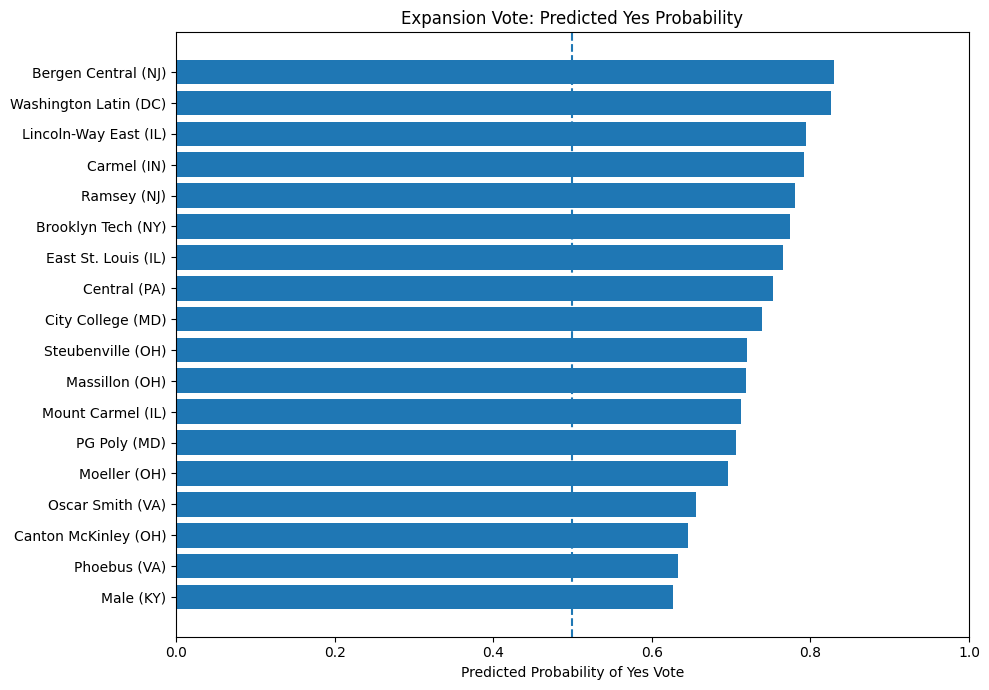

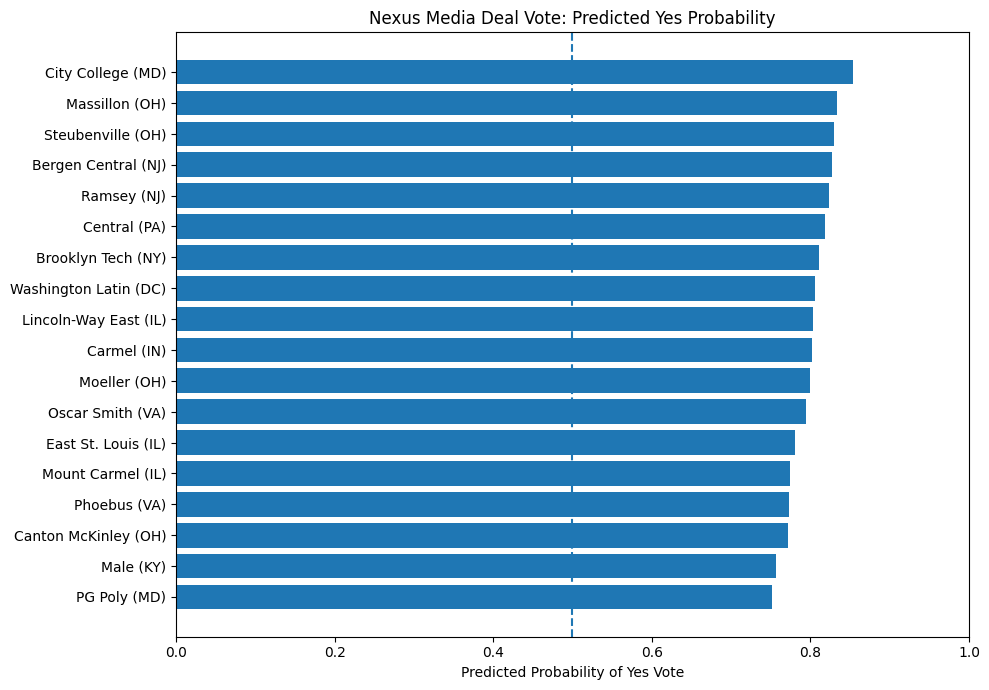

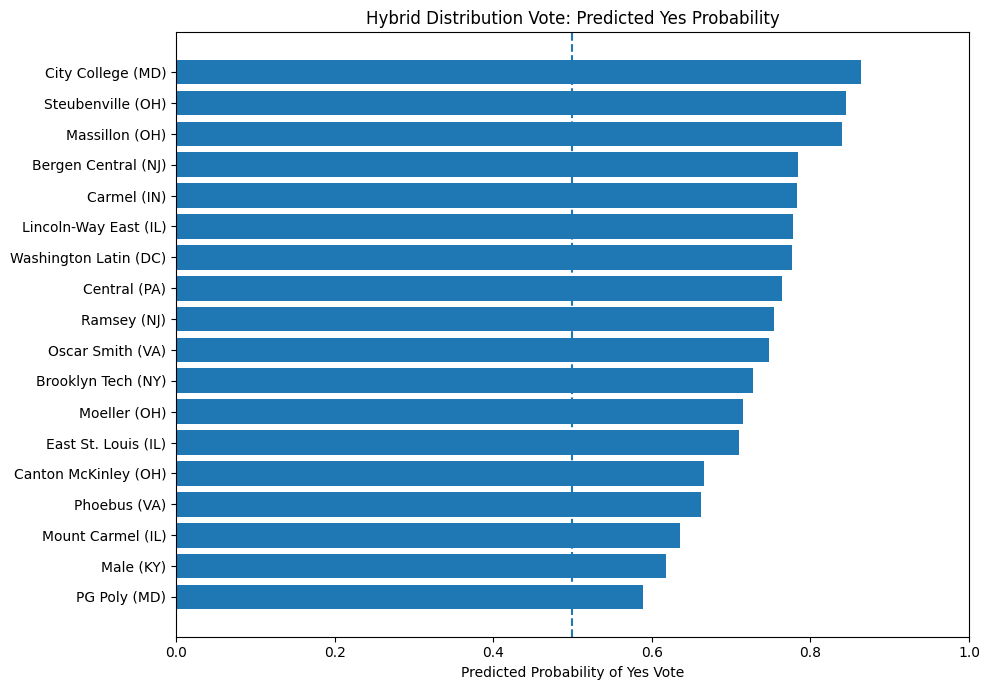

In [11]:
def plot_probability(column, title):
    plot_df = df.sort_values(column, ascending=True)
    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["School"], plot_df[column])
    plt.axvline(0.50, linestyle="--")
    plt.xlabel("Predicted Probability of Yes Vote")
    plt.title(title)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

plot_probability("P_Expansion_Yes", "Expansion Vote: Predicted Yes Probability")
plot_probability("P_Media_Deal_Yes", "Nexus Media Deal Vote: Predicted Yes Probability")
plot_probability("P_Hybrid_Yes", "Hybrid Distribution Vote: Predicted Yes Probability")


## 11. Monte Carlo simulation

In [12]:
def simulate_votes(probabilities, n_sims=10_000, majority_needed=10, uncertainty=0.08):
    probs = np.asarray(probabilities)
    results = []
    for _ in range(n_sims):
        noisy_probs = np.clip(probs + np.random.normal(0, uncertainty, size=len(probs)), 0, 1)
        yes_votes = np.random.binomial(1, noisy_probs).sum()
        results.append(yes_votes)
    results = np.array(results)
    return {
        "mean_yes_votes": results.mean(),
        "median_yes_votes": np.median(results),
        "pass_rate": (results >= majority_needed).mean(),
        "vote_distribution": results
    }

sim_expansion = simulate_votes(df["P_Expansion_Yes"])
sim_media = simulate_votes(df["P_Media_Deal_Yes"])
sim_hybrid = simulate_votes(df["P_Hybrid_Yes"])

sim_summary = pd.DataFrame({
    "Vote": ["Expansion to 18", "Accept Nexus Media Deal", "Adopt Hybrid Distribution"],
    "Mean Yes Votes": [sim_expansion["mean_yes_votes"], sim_media["mean_yes_votes"], sim_hybrid["mean_yes_votes"]],
    "Median Yes Votes": [sim_expansion["median_yes_votes"], sim_media["median_yes_votes"], sim_hybrid["median_yes_votes"]],
    "Pass Rate": [sim_expansion["pass_rate"], sim_media["pass_rate"], sim_hybrid["pass_rate"]]
})

sim_summary["Mean Yes Votes"] = sim_summary["Mean Yes Votes"].round(2)
sim_summary["Pass Rate"] = (sim_summary["Pass Rate"] * 100).round(1).astype(str) + "%"
sim_summary


,Vote,Mean Yes Votes,Median Yes Votes,Pass Rate
0,Expansion to 18,13.16,13.0,97.2%
1,Accept Nexus Media Deal,14.41,15.0,99.6%
2,Adopt Hybrid Distribution,13.25,13.0,97.6%


In [ ]:
def plot_vote_distribution(sim_result, title):
    plt.figure(figsize=(9, 5))
    plt.hist(sim_result["vote_distribution"], bins=np.arange(0, 20) - 0.5, edgecolor="black")
    plt.axvline(10, linestyle="--")
    plt.xlabel("Yes Votes")
    plt.ylabel("Simulation Count")
    plt.title(title)
    plt.xticks(range(0, 19))
    plt.tight_layout()
    plt.show()

plot_vote_distribution(sim_expansion, "Monte Carlo Distribution: Expansion Vote")
plot_vote_distribution(sim_media, "Monte Carlo Distribution: Nexus Media Deal Vote")
plot_vote_distribution(sim_hybrid, "Monte Carlo Distribution: Hybrid Distribution Vote")


## 12. Identify persuadable schools

In [13]:
def persuadable_table(prob_col, vote_name):
    out = df.loc[df[prob_col].between(0.40, 0.60), [
        "School", "Status", "Division", prob_col, "Vote_Blurb"
    ]].copy()
    out[prob_col] = (out[prob_col] * 100).round(1)
    out = out.rename(columns={prob_col: f"{vote_name} Yes Probability"})
    return out.sort_values(f"{vote_name} Yes Probability")

expansion_persuadables = persuadable_table("P_Expansion_Yes", "Expansion")
media_persuadables = persuadable_table("P_Media_Deal_Yes", "Media Deal")
hybrid_persuadables = persuadable_table("P_Hybrid_Yes", "Hybrid")

print("Expansion persuadables")
display(expansion_persuadables)
print("Media deal persuadables")
display(media_persuadables)
print("Hybrid distribution persuadables")
display(hybrid_persuadables)


Expansion persuadables


,School,Status,Division,Expansion Yes Probability,Vote_Blurb


Media deal persuadables


,School,Status,Division,Media Deal Yes Probability,Vote_Blurb


Hybrid distribution persuadables


,School,Status,Division,Hybrid Yes Probability,Vote_Blurb
2,PG Poly (MD),Current,East,58.9,"Benefits from DMV growth, but needs guaranteed..."


## 13. Estimate hybrid performance-pool shares

This is a rough estimate, not a final payment formula. It estimates who benefits from the $450,000 performance pool based on media-driving factors.

In [14]:
df["Performance_Pool_Index"] = (
    0.30 * df["Expected_T1"] +
    0.20 * df["Media_Tier_Score"] +
    0.15 * df["Attendance_Score"] +
    0.15 * df["Utilization_Score"] +
    0.10 * df["Recent_FB_Strength"] +
    0.10 * df["Basketball_Value"]
)

df["Estimated_Performance_Pool_Share"] = df["Performance_Pool_Index"] / df["Performance_Pool_Index"].sum()
df["Estimated_Performance_Bonus"] = df["Estimated_Performance_Pool_Share"] * HYBRID_PERFORMANCE_POOL
df["Estimated_Total_Hybrid_Payout"] = HYBRID_BASE + df["Estimated_Performance_Bonus"]
df["Difference_From_Equal"] = df["Estimated_Total_Hybrid_Payout"] - EQUAL_PAYOUT

payout_table = df[[
    "School", "Status", "Division", "Estimated_Performance_Bonus",
    "Estimated_Total_Hybrid_Payout", "Difference_From_Equal", "Performance_Pool_Index"
]].copy()

for col in ["Estimated_Performance_Bonus", "Estimated_Total_Hybrid_Payout", "Difference_From_Equal"]:
    payout_table[col] = payout_table[col].round(0).astype(int)

payout_table.sort_values("Estimated_Total_Hybrid_Payout", ascending=False)


,School,Status,Division,Estimated_Performance_Bonus,Estimated_Total_Hybrid_Payout,Difference_From_Equal,Performance_Pool_Index
0,City College (MD),Current,East,37118,162118,12118,0.893850
9,Steubenville (OH),Current,West,34122,159122,9122,0.821714
13,Massillon (OH),Current,West,33394,158394,8394,0.804161
16,Lincoln-Way East (IL),Expansion,West,29357,154357,4357,0.706961
14,Washington Latin (DC),Expansion,East,29086,154086,4086,0.700429
15,Bergen Central (NJ),Expansion,East,28808,153808,3808,0.693745
17,Carmel (IN),Expansion,West,27585,152585,2585,0.664284
1,Central (PA),Current,East,26179,151179,1179,0.630421
6,Oscar Smith (VA),Current,East,26115,151115,1115,0.628895
4,Ramsey (NJ),Current,East,25854,150854,854,0.622596


In [ ]:
plt.figure(figsize=(10, 7))
plot_df = payout_table.sort_values("Difference_From_Equal", ascending=True)
plt.barh(plot_df["School"], plot_df["Difference_From_Equal"])
plt.axvline(0, linestyle="--")
plt.xlabel("Estimated Difference from Equal Distribution")
plt.title("Estimated Winners and Losers Under Hybrid Model")
plt.tight_layout()
plt.show()


## 14. Commissioner-facing decision summary

In [16]:
def summarize_vote(label, yes_votes, no_votes, pass_rate):
    result = "passes" if yes_votes >= 10 else "fails"
    return f"{label}: deterministic vote is {yes_votes}-{no_votes}; proposal {result}. Monte Carlo pass rate: {pass_rate:.1%}."

exp_yes = (df["Expansion_Vote"] == "Yes").sum()
exp_no = 18 - exp_yes
media_yes = (df["Media_Deal_Vote"] == "Yes").sum()
media_no = 18 - media_yes
hybrid_yes = (df["Hybrid_Vote"] == "Yes").sum()
hybrid_no = 18 - hybrid_yes

print(summarize_vote("Expansion to 18", exp_yes, exp_no, sim_expansion["pass_rate"]))
print(summarize_vote("Accept Nexus media deal", media_yes, media_no, sim_media["pass_rate"]))
print(summarize_vote("Adopt hybrid distribution", hybrid_yes, hybrid_no, sim_hybrid["pass_rate"]))
print("
Most important hybrid persuadables:")
display(hybrid_persuadables)


SyntaxError: unterminated string literal (detected at line 15) (1405965918.py, line 15)

## 15. Export results

In [17]:
output_vote_table = vote_table.copy()
output_payout_table = payout_table.copy()

output_vote_table.to_csv("alliance_governance_vote_predictions.csv", index=False)
output_payout_table.to_csv("alliance_hybrid_distribution_estimates.csv", index=False)

print("Exported:")
print("- alliance_governance_vote_predictions.csv")
print("- alliance_hybrid_distribution_estimates.csv")


Exported:
- alliance_governance_vote_predictions.csv
- alliance_hybrid_distribution_estimates.csv
